## Implementing a GPT model from scratch to generate text

In [1]:
GPT_CONFIG_124M = {
 "vocab_size": 50257, # Vocabulary size|
 "context_length": 1024, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "qkv_bias": False # Query-Key-Value bias
}

In [2]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
            for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    def forward(self, x):
        return x
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps = 1e-5):
        super().__init__()
    def forward(self, x):
        return x

In [3]:
# prepping da data
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### LayerNorm
Deep NNs have a vanishing & exploding gradient problem - i.e. unstable training. **LayerNorm** can improve the stability and efficiency of NN training. Pretty simple concept, just adjust the activations (outputs) of a NN to have a mean of 0 and a variance of 1. 

Typically in modern transformer architectures we apply LayerNorm before and after the multi-head attention module.

In [5]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim = 1, keepdim=True)
        var = x.var(dim = 1, keepdim=True)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

ln = LayerNorm(emb_dim = 6)
out_ln = ln(out)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
Mean:
 tensor([[-1.9868e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.8330],
        [0.8331]], grad_fn=<VarBackward0>)


### GELU & A FFN
In LLMs, several other activation functions that are not ReLU are employed beyond the traditional ReLU. Two notable examples are GELU (Gaussian error linear unit) and SwiGLU
(Swish-gated linear unit)

 The GELU activation function can be implemented in several ways; the exact version is defined as GELU(x) = x⋅Φ(x), where Φ(x) is the cumulative distribution function of the standard Gaussian distribution. In practice, however, it’s common to
implement a computationally cheaper approximation (the original GPT-2 model was
also trained with this approximation, which was found via curve fitting):

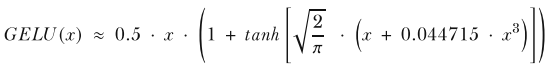

In [6]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2 / torch.pi)) *
            (x + 0.044715 + torch.pow(x, 3))
        ))

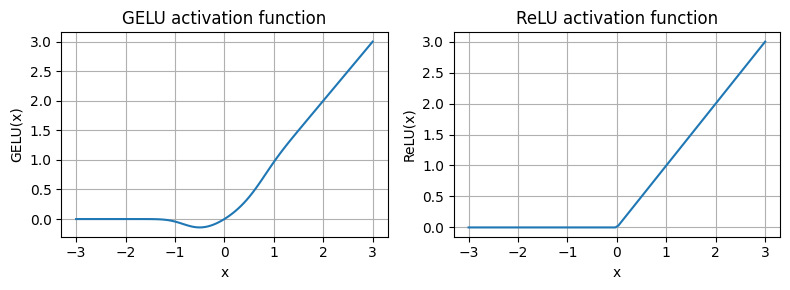

In [7]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
 plt.subplot(1, 2, i)
 plt.plot(x, y)
 plt.title(f"{label} activation function")
 plt.xlabel("x")
 plt.ylabel(f"{label}(x)")
 plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),
            GELU(),
            nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim'])
        )
    def forward(self, x):
        return self.layers(x)

In [9]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


### Shortcut Connections
Let’s discuss the concept behind shortcut connections, also known as skip or residual
connections. Originally, shortcut connections were proposed for deep networks in
computer vision (specifically, in residual networks) to mitigate the challenge of vanishing gradients. The vanishing gradient problem refers to the issue where gradients
(which guide weight updates during training) become progressively smaller as they
propagate backward through the layers, making it difficult to effectively train earlier
layers.

Figure 4.12 shows that a shortcut connection creates an alternative, shorter path
for the gradient to flow through the network by skipping one or more layers, which is
achieved by adding the output of one layer to the output of a later layer. This is why
these connections are also known as skip connections. They play a crucial role in preserving the flow of gradients during the backward pass in training. 

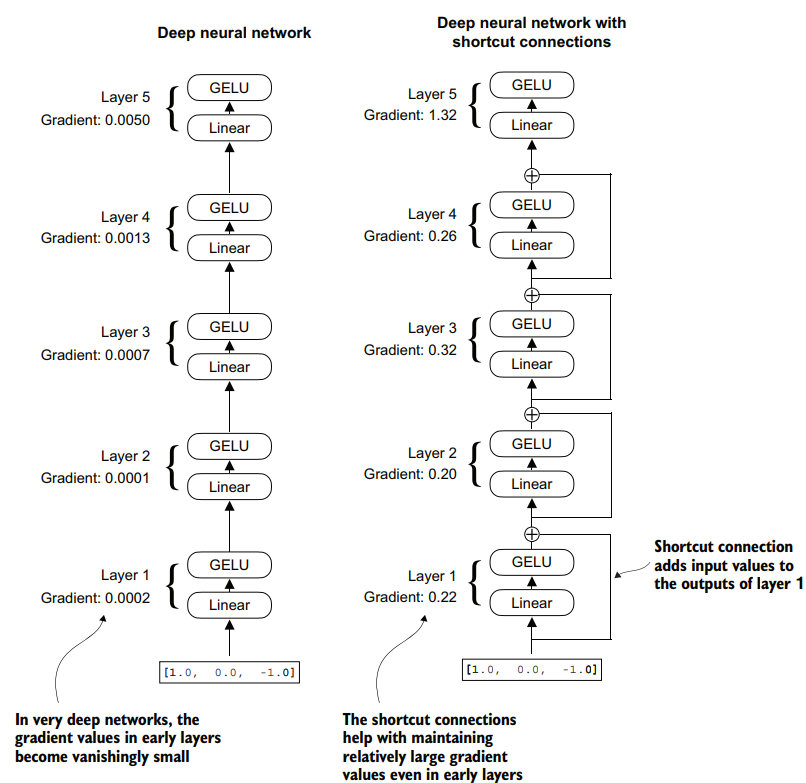

In [10]:
## an example nn w/ a residual connection

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU())
        ])
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
 layer_sizes, use_shortcut=False
)

def print_gradients(model, x):
 output = model(x)
 target = torch.tensor([[0.]])
 loss = nn.MSELoss()
 loss = loss(output, target)
 loss.backward()

 for name, param in model.named_parameters():
     if 'weight' in name:
         print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

print_gradients(model_without_shortcut, sample_input)

torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
 layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0007728282362222672
layers.1.0.weight has gradient mean of 0.0004728951316792518
layers.2.0.weight has gradient mean of 0.0027202058117836714
layers.3.0.weight has gradient mean of 0.004806114360690117
layers.4.0.weight has gradient mean of 0.005875842645764351
layers.0.0.weight has gradient mean of 0.665235698223114
layers.1.0.weight has gradient mean of 0.5565143823623657
layers.2.0.weight has gradient mean of 0.7957727313041687
layers.3.0.weight has gradient mean of 0.4990907907485962
layers.4.0.weight has gradient mean of 0.623001217842102


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


### Connecting Attention & Linear Layers in a Transformer Block

In [11]:
# return to implementing MHA :D
import torch
import torch.nn as nn

# qkv
# mask
# multihead
# dropout
# outer matrix
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, num_heads, dropout, context_length, qkv_bias = False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.num_heads = num_heads
        self.d_h = d_out // num_heads
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal = 1)
        )
        self.dropout = nn.Dropout(dropout)
        self.W_out = nn.Linear(d_out, d_out)
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.d_h)       
        keys = keys.view(b, num_tokens, self.num_heads, self.d_h)       
        values = values.view(b, num_tokens, self.num_heads, self.d_h)   

        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores = attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / self.d_h ** 0.5, dim = -1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values.transpose(1, 2)
        context_vec = context_vec.transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.W_out(context_vec)
        return context_vec

In [12]:
# prepping da data
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you a little closer to"
txt2 = "Every day holds an opportunity to move a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

context_length = 8
output_dim = 768

embedding_layer = nn.Embedding(tokenizer.n_vocab, output_dim)
pos_embedding_layer = nn.Embedding(context_length, output_dim)

embeddings = embedding_layer(batch)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))

input = embeddings + pos_embeddings
input.shape

torch.Size([2, 8, 768])

In [13]:
mha = MultiHeadAttention(768, 768, 4, 0.5, 8)
mha(input)

tensor([[[ 0.5838,  0.3727, -0.5955,  ...,  0.1953,  0.4485,  1.0183],
         [ 0.1214, -0.0476,  0.0734,  ...,  0.2821,  0.1987,  0.2613],
         [-0.0331, -0.1734,  0.1371,  ...,  0.6548,  0.0622, -0.2835],
         ...,
         [-0.1383,  0.1024,  0.4568,  ...,  0.2287, -0.1927,  0.3526],
         [-0.1901, -0.5558,  0.3697,  ..., -0.0454, -0.2508,  0.6481],
         [-0.1095,  0.0151,  0.3980,  ...,  0.2370, -0.2500,  0.3997]],

        [[ 0.1989,  0.6207,  1.3312,  ..., -0.8697, -0.4360, -0.1038],
         [ 0.2161,  0.1487, -0.2341,  ..., -0.4245,  0.1788,  1.3008],
         [ 0.1540,  0.2282,  0.7668,  ..., -0.4196,  0.0653,  1.0618],
         ...,
         [ 0.1028,  0.1331,  0.5135,  ..., -0.2128, -0.1175,  0.3422],
         [-0.3394,  0.0076, -0.0982,  ..., -0.0121, -0.1594,  0.1580],
         [ 0.3537, -0.4268, -0.1401,  ...,  0.3417, -0.2900,  0.4205]]],
       grad_fn=<ViewBackward0>)

In [14]:
![image.png](attachment:image.png)

/bin/bash: -c: line 1: syntax error near unexpected token `attachment:image.png'
/bin/bash: -c: line 1: `[image.png](attachment:image.png)'


## Time to Implement an Actual Transformer Block

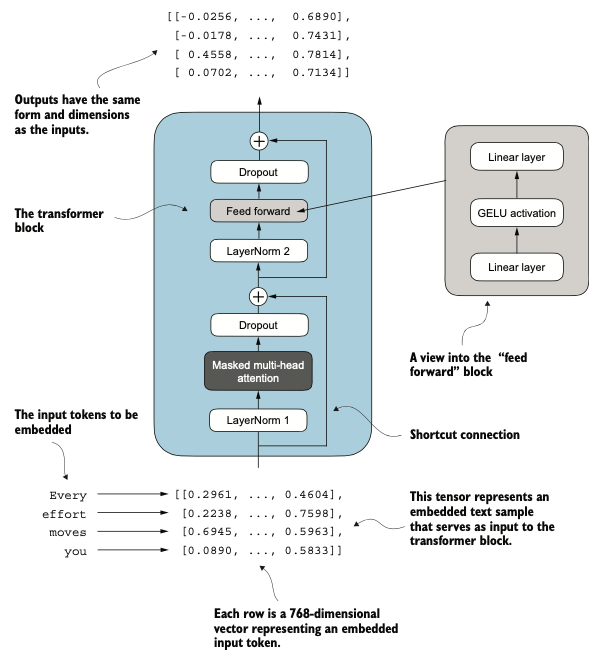

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length = cfg["context_length"],
            num_heads = cfg["n_heads"],
            dropout = cfg["drop_rate"],
            qkv_bias = cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm1(x)
        x = self.ffn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x